# Golden sweeps on $25k, beta-hedged with SPY shares

Vendor-flagged **golden** sweeps, ISO only, over the twelve expiry cycles the earnings
calendar covers (2025-10-17 .. 2026-09-18). One question: can a $25,000 account trade
them while hedging its SPY beta with **shares**?

The hedge is **portfolio-net**, not per position. Each option contributes
`beta x delta x 100 x contracts x spot` of market exposure; long calls and long puts push
opposite ways, so the book needs far less SPY than hedging each leg separately. That
distinction is the whole feasibility question at this account size.

**What is modelled and what is not.** Entry is a real traded option fill from Quant Data.
After entry the contract is marked with Black-Scholes off the vol implied by that fill,
held constant, along the underlying's 15-minute closes, settling at real intrinsic. The
SPY leg is marked close to close on real SPY bars. No borrow, no dividends, no
commissions, and no margin interest.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "research" / "sweep_events"))
import directional as D           # noqa: E402
import event_study as E           # noqa: E402
import exit_rules as X            # noqa: E402
import stopping as S              # noqa: E402

pd.set_option("display.width", 170, "display.max_columns", 50)

ACCOUNT   = 25_000.0
POS_PCT   = 0.20          # 20% of the account a position -> $5,000
MARGIN    = 0.50          # Reg T initial on the SPY leg, either side
COVER_FROM = "2025-10-01" # the earnings calendar's first date; before this the veto is blind

flow   = D.load()
trades = pd.read_parquet(ROOT / "data" / "dashboard_trades.parquet")
bars   = E.load_bars()
print(f"flow {len(flow):,} ISO prints  {flow.session.min()} .. {flow.session.max()}")
print(f"trade log {len(trades):,} rows, {int(trades.simulable.sum()):,} simulable")

flow 156,460 ISO prints  2024-12-02 .. 2026-09-21
trade log 3,046 rows, 1,108 simulable


## 1. The universe, and what falls out of it

`isGoldenSweep` is the vendor's own badge. It is **not** the ISO screen — the two
populations only partly overlap, which is why the funnel below loses two thirds of the
prints before anything is priced.

In [2]:
g = flow[flow.isGoldenSweep == True].copy()
g["entry_ts"] = g.ts.dt.tz_convert("America/New_York").dt.tz_localize(None)
g["sess"] = pd.to_datetime(g.session)
yr = g[g.sess >= COVER_FROM].copy()

log = trades.copy()
log["entry_ts"] = pd.to_datetime(log.entry_ts)
m = yr.merge(log[["ticker", "entry_ts", "simulable", "contract_cost", "beta", "expiry",
                  "direction", "ret", "strike", "right", "entry_price", "entry_iv",
                  "confirm_ts", "confirm_spot", "exit_spot", "exit_price", "vol_oi"]],
             on=["ticker", "entry_ts"], how="left", suffixes=("", "_log"))

funnel = pd.DataFrame([
    ("golden prints, all cached flow",        len(g)),
    (f"... inside earnings coverage ({COVER_FROM}+)", len(yr)),
    ("... screened in by directional.triggers", int(m.simulable.notna().sum())),
    ("... with a real fill and a settlement",  int((m.simulable == True).sum())),
], columns=["step", "n"])
print(funnel.to_string(index=False))

miss = m[m.simulable.isna()]
print(f"\nnever screened in ({len(miss)}): "
      f"|delta| outside 0.30-0.70 {int((~miss.absdelta.between(.3,.7)).sum())} · "
      f"fund/ETF {int(miss.isETF.fillna(False).sum())} · no aggressor side {int(miss.direction.isna().sum())}")

                                      step    n
            golden prints, all cached flow 1438
... inside earnings coverage (2025-10-01+)  944
   ... screened in by directional.triggers  459
     ... with a real fill and a settlement  307

never screened in (497): |delta| outside 0.30-0.70 264 · fund/ETF 242 · no aggressor side 3


In [3]:
sig = m[m.simulable == True].copy()
sig["cycle"] = sig.expiry
print(f"{len(sig)} tradeable golden sweeps · {sig.ticker.nunique()} tickers · {sig.cycle.nunique()} cycles")
print(f"direction {sig.direction_log.value_counts().to_dict()} · beta present {int(sig.beta.notna().sum())}")
sig.groupby("cycle").agg(n=("ret", "size"), bull=("direction_log", lambda s: (s == "BULL").sum()),
                         hold_mean=("ret", "mean"), hold_median=("ret", "median"))

307 tradeable golden sweeps · 87 tickers · 12 cycles
direction {'BULL': 205, 'BEAR': 102} · beta present 204


,n,bull,hold_mean,hold_median
cycle,,,,
2025-10-17,11,9,-0.030707,-0.305000
2025-11-21,8,5,1.363500,0.747150
2025-12-19,29,17,0.358997,-0.092166
2026-01-16,19,14,-0.143231,-1.000000
2026-02-20,35,22,-0.497318,-1.000000
2026-03-20,27,17,-0.061184,-1.000000
2026-04-17,25,14,0.961702,0.727368
2026-05-15,44,36,1.015369,0.309638
2026-06-18,47,31,0.185284,-0.277348


## 2. What $25,000 can actually hold

At 20% a position the budget is $5,000. Whole contracts only, and a signal whose single
contract costs more than the budget is skipped rather than sized up.

In [4]:
sig["contracts"] = np.floor(ACCOUNT * POS_PCT / sig.contract_cost).astype(int)
sig["cost"] = sig.contracts * sig.contract_cost
took = sig[sig.contracts > 0].copy()
print(f"affordable at ${ACCOUNT*POS_PCT:,.0f}: {len(took)} of {len(sig)} "
      f"({len(took)/len(sig):.0%}); {len(sig)-len(took)} skipped as one contract > budget")
print(f"contracts per position: median {took.contracts.median():.0f}  max {took.contracts.max()}")
print(f"capital per position: median ${took.cost.median():,.0f}  max ${took.cost.max():,.0f}")

# how many run at once, and what that costs in cash alone
ent = pd.to_datetime(took.confirm_ts).dt.normalize()
exp = pd.to_datetime(took.expiry)
days = pd.date_range(ent.min(), exp.max(), freq="B")
conc = pd.DataFrame({
    "open": [(ent.le(d) & exp.ge(d)).sum() for d in days],
    "cash": [took.cost[(ent.le(d) & exp.ge(d)).values].sum() for d in days],
}, index=days)
print(f"\nconcurrent positions: mean {conc.open.mean():.1f}  max {conc.open.max()}")
print(f"premium outstanding:  mean ${conc.cash.mean():,.0f}  max ${conc.cash.max():,.0f}"
      f"   <- against a ${ACCOUNT:,.0f} account")

affordable at $5,000: 284 of 307 (93%); 23 skipped as one contract > budget
contracts per position: median 4  max 625
capital per position: median $4,561  max $5,000

concurrent positions: mean 17.6  max 53
premium outstanding:  mean $75,494  max $225,356   <- against a $25,000 account


**Read that last line before going further.** If peak premium outstanding already exceeds
the account, the strategy is capital-infeasible before a single share of SPY is shorted,
and the hedge only adds to the requirement.

## 3. The unhedged book

Paths first: every position marked bar by bar so the hedge can re-read its delta.

In [5]:
paths = X.build_paths(took.set_index(pd.Index(range(len(took)))), bars)
took = took.reset_index(drop=True)
print(f"paths built for {len(paths)} of {len(took)} positions")

rows = []
for i, p in paths.items():
    t = took.loc[i]
    rows.append({"i": i, "ticker": t.ticker, "cycle": t.cycle, "direction": t.direction_log,
                 "contracts": int(t.contracts), "entry": p["entry"],
                 "hold_ret": p["settle"] / p["entry"] - 1,
                 "pnl_hold": (p["settle"] - p["entry"]) * 100 * int(t.contracts),
                 "beta": t.beta})
book = pd.DataFrame(rows)
print(f"\nhold to expiry: n={len(book)}  win {(book.pnl_hold>0).mean():.0%}  "
      f"mean {book.hold_ret.mean():+.1%}  median {book.hold_ret.median():+.1%}  "
      f"total ${book.pnl_hold.sum():,.0f}  ({book.pnl_hold.sum()/ACCOUNT:+.0%} of the account)")
book.groupby("cycle").agg(n=("pnl_hold","size"), mean=("hold_ret","mean"), pnl=("pnl_hold","sum")).round(3)

paths built for 284 of 284 positions

hold to expiry: n=284  win 41%  mean +23.4%  median -46.9%  total $250,512  (+1002% of the account)


,n,mean,pnl
cycle,,,
2025-10-17,11,-0.031,-1128.0
2025-11-21,8,1.364,34113.0
2025-12-19,29,0.359,35154.0
2026-01-16,19,-0.143,-11772.0
2026-02-20,35,-0.497,-84138.0
2026-03-20,17,0.101,6554.0
2026-04-17,24,1.043,111435.0
2026-05-15,44,1.015,186987.0
2026-06-18,38,0.241,32535.0


## 4. The SPY hedge, netted across the book

At each session close: sum `beta x delta x 100 x contracts x spot` over every open
position, short that many dollars of SPY, and mark the previous day's leg to today's move.
Delta is re-read from the path each session, so the hedge follows the position as it moves
in or out of the money.

Positions without 120 sessions of history have no beta and are left unhedged — counted,
not silently dropped.

In [6]:
def session_closes(sym="SPY"):
    b = bars[sym]
    st = S.sessionStarts(b) if hasattr(S, "sessionStarts") else None
    ts = b["ts"].values
    gaps = np.diff(ts).astype("timedelta64[m]").astype(int) > 120
    last = np.flatnonzero(np.r_[gaps, True])
    return last

spy = bars["SPY"].reset_index(drop=True)
closes = session_closes()
spy_t = spy["ts"].values

live = []
for i, p in paths.items():
    t = took.loc[i]
    if pd.isna(t.beta):
        continue
    live.append({"i": i, "p": p, "beta": float(t.beta), "K": float(t.strike),
                 "sig": float(t.entry_iv), "right": t.right, "n": int(t.contracts),
                 "a": p["ts"][0] if "ts" in p else None})
print(f"hedgeable: {len(live)} of {len(paths)} positions "
      f"({len(paths)-len(live)} have no beta and run unhedged)")

hedgeable: 204 of 284 positions (80 have no beta and run unhedged)


In [7]:
def bs_delta(Sx, K, tau, sig, right):
    if tau <= 1e-7 or sig <= 0:
        return (1.0 if Sx > K else 0.0) if right == "CALL" else (-1.0 if Sx < K else 0.0)
    from scipy.stats import norm
    d1 = (np.log(Sx / K) + 0.5 * sig * sig * tau) / (sig * np.sqrt(tau))
    return float(norm.cdf(d1)) if right == "CALL" else float(norm.cdf(d1) - 1.0)

# per-position bar timestamps and taus, rebuilt on build_paths' own convention
meta = {}
for L in live:
    i, p = L["i"], L["p"]
    t = took.loc[i]
    b = bars[t.ticker]
    ts = b["ts"].values
    i0 = int(np.searchsorted(ts, np.datetime64(pd.Timestamp(t.confirm_ts))))
    end = pd.Timestamp(t.expiry) + pd.Timedelta(hours=16)
    j1 = int(np.searchsorted(ts, np.datetime64(end)))
    mins = (end - pd.to_datetime(ts[i0:j1])).total_seconds() / 60.0 - 15.0
    meta[i] = {"ts": ts[i0:j1], "tau": np.maximum(0.0, mins) / (60 * 24 * 365)}

recs, cum, prev_sh, prev_px = [], 0.0, 0.0, None
for ci in closes:
    now, px = spy_t[ci], float(spy["close"].iloc[ci])
    if prev_px is not None:
        cum += prev_sh * (px - prev_px)
    expo, n_open = 0.0, 0
    for L in live:
        M = meta[L["i"]]
        if now < M["ts"][0] or now > M["ts"][-1]:
            continue
        j = min(int(np.searchsorted(M["ts"], now)), len(M["ts"]) - 1)
        d = bs_delta(L["p"]["spot"][j], L["K"], M["tau"][j], L["sig"], L["right"])
        expo += L["beta"] * d * 100 * L["n"] * L["p"]["spot"][j]
        n_open += 1
    sh = -expo / px if px else 0.0
    recs.append({"ts": pd.Timestamp(now), "spy": px, "expo": expo, "shares": sh,
                 "open": n_open, "hedge_cum": cum, "notional": abs(sh) * px})
    prev_sh, prev_px = sh, px

hedge = pd.DataFrame(recs).set_index("ts")
print(f"hedge P&L: ${hedge.hedge_cum.iloc[-1]:,.0f}")
print(f"net exposure: mean ${hedge.expo.mean():,.0f}  |mean| ${hedge.expo.abs().mean():,.0f}  "
      f"peak |.| ${hedge.expo.abs().max():,.0f}")
print(f"SPY notional held: mean ${hedge.notional.mean():,.0f}  peak ${hedge.notional.max():,.0f}")
print(f"Reg T margin at {MARGIN:.0%}: mean ${hedge.notional.mean()*MARGIN:,.0f}  "
      f"peak ${hedge.notional.max()*MARGIN:,.0f}   <- against ${ACCOUNT:,.0f}")

hedge P&L: $-65,803
net exposure: mean $497,185  |mean| $591,574  peak |.| $7,030,100
SPY notional held: mean $591,574  peak $7,030,100
Reg T margin at 50%: mean $295,787  peak $3,515,050   <- against $25,000


## 5. Does it fit in the account?

Buying power needed on any day is premium outstanding **plus** Reg T margin on the SPY leg.
Anything above the account line is a position the account could not have carried.

In [8]:
cash = conc.reindex(hedge.index.normalize(), method="ffill")["cash"].values
need = pd.DataFrame({"premium": cash,
                     "spy_margin": hedge.notional.values * MARGIN}, index=hedge.index)
need["total"] = need.premium + need.spy_margin
over = (need.total > ACCOUNT).mean()
print(f"buying power needed: mean ${need.total.mean():,.0f}  peak ${need.total.max():,.0f}")
print(f"days over the ${ACCOUNT:,.0f} account: {over:.0%}")
print(f"account multiple needed to run it unconstrained: {need.total.max()/ACCOUNT:.1f}x")
need.describe().loc[["mean", "50%", "max"]].round(0)

buying power needed: mean $374,072  peak $3,735,651
days over the $25,000 account: 93%
account multiple needed to run it unconstrained: 149.4x


,premium,spy_margin,total
mean,75861.0,295787.0,374072.0
50%,65948.0,126461.0,199365.0
max,225356.0,3515050.0,3735651.0


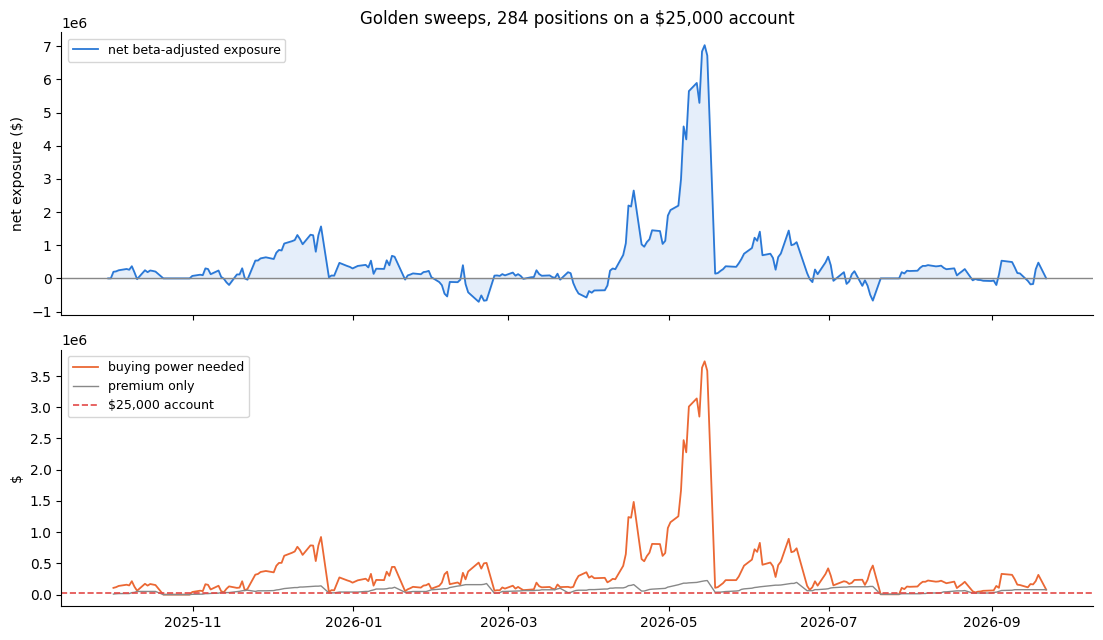

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, height_ratios=[1.1, 1])
ax[0].plot(hedge.index, hedge.expo, lw=1.3, color="#2a78d6", label="net beta-adjusted exposure")
ax[0].axhline(0, color="#888", lw=1)
ax[0].fill_between(hedge.index, 0, hedge.expo, color="#2a78d6", alpha=.12)
ax[0].set_ylabel("net exposure ($)"); ax[0].legend(loc="upper left", fontsize=9)
ax[0].set_title(f"Golden sweeps, {len(book)} positions on a ${ACCOUNT:,.0f} account")
ax[1].plot(need.index, need.total, lw=1.3, color="#eb6834", label="buying power needed")
ax[1].plot(need.index, need.premium, lw=1, color="#888", label="premium only")
ax[1].axhline(ACCOUNT, color="#e34948", ls="--", lw=1.2, label=f"${ACCOUNT:,.0f} account")
ax[1].set_ylabel("$"); ax[1].legend(loc="upper left", fontsize=9)
for a in ax: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 6. Hedged vs unhedged

The hedge removes the market factor. Whether it removes *risk* is a separate question —
a long option is convex and a linear SPY leg is not.

In [10]:
opt_total = book.pnl_hold.sum()
hed_total = hedge.hedge_cum.iloc[-1]
summary = pd.DataFrame([
    ("options only",      opt_total, opt_total / ACCOUNT),
    ("SPY hedge leg",     hed_total, hed_total / ACCOUNT),
    ("net of hedge",      opt_total + hed_total, (opt_total + hed_total) / ACCOUNT),
], columns=["arm", "pnl", "on_account"])
print(summary.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

by_dir = book.groupby("direction").agg(n=("pnl_hold","size"), mean=("hold_ret","mean"),
                                       median=("hold_ret","median"), pnl=("pnl_hold","sum"))
print("\nby direction (options only):")
print(by_dir.round(3).to_string())

rng = np.random.default_rng(0)
tk = book.ticker.unique()
bs = np.array([book[book.ticker.isin(rng.choice(tk, len(tk)))].hold_ret.mean() for _ in range(4000)])
print(f"\nmean return {book.hold_ret.mean():+.1%}  95% CI clustered by ticker "
      f"[{np.percentile(bs,2.5):+.1%}, {np.percentile(bs,97.5):+.1%}]  P(<=0)={np.mean(bs<=0):.0%}")
top = book.nlargest(5, "pnl_hold")
print(f"top 5 positions = ${top.pnl_hold.sum():,.0f} of ${opt_total:,.0f} "
      f"({top.pnl_hold.sum()/opt_total:.0%}): {', '.join(top.ticker)}")

          arm        pnl  on_account
 options only 250,512.00       10.02
SPY hedge leg -65,803.26       -2.63
 net of hedge 184,708.74        7.39

by direction (options only):
             n   mean  median       pnl
direction                              
BEAR        89 -0.112  -0.679  -46157.0
BULL       195  0.391  -0.261  296669.0



mean return +23.4%  95% CI clustered by ticker [+2.4%, +41.8%]  P(<=0)=1%
top 5 positions = $153,789 of $250,512 (61%): PANW, IMO, GOOG, NBIS, MU


## 5b. Hedging with ES / MES futures instead of shares

Shares are the wrong instrument at this account size. Reg T wants 50% of notional; a
futures contract posts a performance bond that is a few percent of notional, so the same
hedge costs roughly an order of magnitude less buying power.

Two instruments, both cash-settled on the S&P 500:

| | multiplier | notional at SPX ~7,735 | typical overnight margin |
|---|---|---|---|
| **ES** (E-mini) | $50 x index | ~$387,000 | ~$17,600 |
| **MES** (Micro) | $5 x index | ~$38,700 | ~$1,760 |

Margin is a parameter below, not a fact — CME sets performance bonds by volatility regime
and brokers add their own cushion, so check your own before trusting the total. The index
level is taken as `SPY x 10`, which is close enough for sizing but is not exact: ES tracks
the price index while SPY holds dividends, so the two drift slightly over a hold.

In [11]:
ES_MULT, MES_MULT = 50.0, 5.0
ES_MARGIN, MES_MARGIN = 17_600.0, 1_760.0     # overnight bond, adjust to your broker
SPX = hedge.spy * 10.0                         # index proxy

fut = pd.DataFrame(index=hedge.index)
fut["spx"] = SPX
fut["target"] = -hedge.expo                    # dollars of index exposure wanted
for tag, mult, marg in [("es", ES_MULT, ES_MARGIN), ("mes", MES_MULT, MES_MARGIN)]:
    notional = SPX * mult
    raw = fut.target / notional
    n = np.round(raw)                           # whole contracts only
    fut[f"{tag}_n"] = n
    fut[f"{tag}_residual"] = fut.target - n * notional
    fut[f"{tag}_margin"] = n.abs() * marg

print(f"{'':<22}{'contracts (mean)':>18}{'margin mean':>14}{'margin peak':>14}{'residual |mean|':>17}")
for tag, lbl in [("es", "ES  (E-mini)"), ("mes", "MES (Micro)")]:
    print(f"  {lbl:<20}{fut[f'{tag}_n'].abs().mean():>18.1f}"
          f"{fut[f'{tag}_margin'].mean():>14,.0f}{fut[f'{tag}_margin'].max():>14,.0f}"
          f"{fut[f'{tag}_residual'].abs().mean():>17,.0f}")
print(f"\nshares, Reg T 50% for comparison: margin mean ${hedge.notional.mean()*MARGIN:,.0f}"
      f"  peak ${hedge.notional.max()*MARGIN:,.0f}")

                        contracts (mean)   margin mean   margin peak  residual |mean|
  ES  (E-mini)                       1.6        28,403       334,400           81,802
  MES (Micro)                       16.5        28,976       330,880            7,880

shares, Reg T 50% for comparison: margin mean $295,787  peak $3,515,050


**Granularity is why MES and not ES.** One ES is ~$387k of notional against a book whose
mean net exposure is ~$592k — you are choosing between one contract and two, and the
rounding error is larger than most of the positions being hedged. MES is a tenth of that,
so the residual unhedged exposure stays small relative to the book.

In [12]:
need_f = pd.DataFrame(index=hedge.index)
need_f["premium"] = need.premium.values
for tag, lbl in [("shares", None), ("es", "es"), ("mes", "mes")]:
    if tag == "shares":
        need_f["shares_total"] = need.premium.values + hedge.notional.values * MARGIN
    else:
        need_f[f"{tag}_total"] = need.premium.values + fut[f"{tag}_margin"].values

print(f"  {'hedge instrument':<22}{'BP mean':>12}{'BP peak':>13}{'days over $25k':>16}{'account x':>11}")
for col, lbl in [("shares_total", "SPY shares (Reg T)"), ("es_total", "ES futures"), ("mes_total", "MES futures")]:
    v = need_f[col]
    print(f"  {lbl:<22}{v.mean():>12,.0f}{v.max():>13,.0f}{(v>ACCOUNT).mean():>15.0%}{v.max()/ACCOUNT:>11.0f}x")

print(f"\nfor reference, premium alone: mean ${need_f.premium.mean():,.0f}  peak ${need_f.premium.max():,.0f}"
      f"  days over ${ACCOUNT:,.0f}: {(need_f.premium>ACCOUNT).mean():.0%}")

  hedge instrument           BP mean      BP peak  days over $25k  account x
  SPY shares (Reg T)         374,072    3,735,651            93%        149x
  ES futures                 104,497      555,001            91%         22x
  MES futures                105,074      551,481            89%         22x

for reference, premium alone: mean $75,861  peak $225,356  days over $25,000: 85%


### What the futures hedge does and does not fix

Futures collapse the hedge's margin, but the hedge was never the only problem. Compare the
three lines above against **premium alone** — the cash tied up in the options themselves,
which no hedging instrument touches. Whichever line is larger is the real constraint.

In [13]:
binding = pd.DataFrame({
    "premium only":        [need_f.premium.mean(), need_f.premium.max(), (need_f.premium > ACCOUNT).mean()],
    "MES margin only":     [fut.mes_margin.mean(), fut.mes_margin.max(), (fut.mes_margin > ACCOUNT).mean()],
    "both (MES)":          [need_f.mes_total.mean(), need_f.mes_total.max(), (need_f.mes_total > ACCOUNT).mean()],
}, index=["mean $", "peak $", "share of days over $25k"]).T
print(binding.to_string(float_format=lambda x: f"{x:,.2f}"))

share = fut.mes_margin.mean() / need_f.mes_total.mean()
print(f"\nthe MES hedge is {share:.0%} of total buying power; the options are {1-share:.0%}")
print("the binding constraint is " + ("the option premium" if need_f.premium.mean() > fut.mes_margin.mean() else "the hedge"))

                    mean $     peak $  share of days over $25k
premium only     75,860.77 225,356.00                     0.85
MES margin only  28,975.61 330,880.00                     0.29
both (MES)      105,073.89 551,481.00                     0.89

the MES hedge is 28% of total buying power; the options are 72%
the binding constraint is the option premium


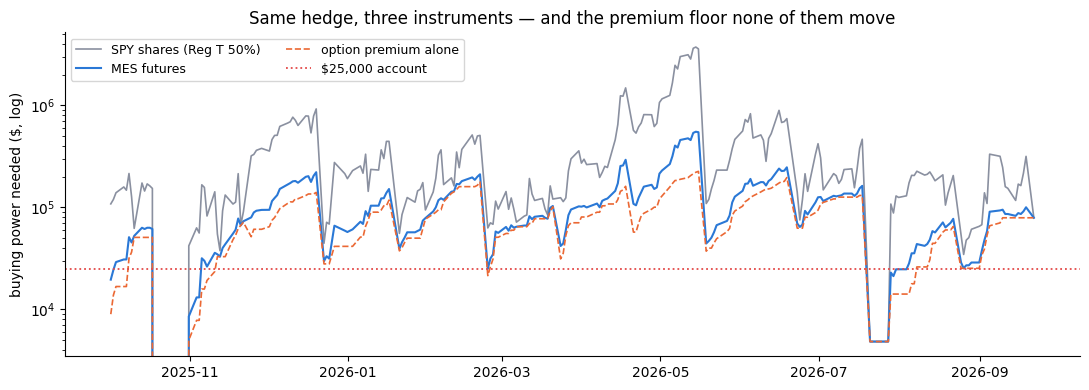

In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(need_f.index, need_f.shares_total, lw=1.2, color="#8a90a0", label="SPY shares (Reg T 50%)")
ax.plot(need_f.index, need_f.mes_total, lw=1.5, color="#2a78d6", label="MES futures")
ax.plot(need_f.index, need_f.premium, lw=1.2, color="#eb6834", ls="--", label="option premium alone")
ax.axhline(ACCOUNT, color="#e34948", lw=1.3, ls=":", label=f"${ACCOUNT:,.0f} account")
ax.set_yscale("log"); ax.set_ylabel("buying power needed ($, log)")
ax.set_title("Same hedge, three instruments — and the premium floor none of them move")
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### Sizing it to actually fit

If the premium line is the binding constraint, the only lever that works is **fewer or
smaller positions** — a cap on concurrent positions, not a smaller hedge. The cell below
sweeps a hard cap and reports what each one costs in signals skipped.

In [15]:
def run_cap(cap, pos_pct=POS_PCT):
    budget = ACCOUNT * pos_pct
    open_until, taken = [], []
    for r in took.sort_values("confirm_ts").itertuples():
        t0, t1 = pd.Timestamp(r.confirm_ts), pd.Timestamp(r.expiry)
        open_until = [x for x in open_until if x > t0]
        if len(open_until) >= cap:
            continue
        n = int(np.floor(budget / r.contract_cost))
        if n < 1:
            continue
        open_until.append(t1); taken.append((r.Index, n))
    idx = [i for i, _ in taken]
    sub = book[book.i.isin(idx)] if "i" in book.columns else book.loc[book.index.isin(idx)]
    scale = {i: n for i, n in taken}
    pnl = sum((paths[i]["settle"] - paths[i]["entry"]) * 100 * scale[i] for i in idx if i in paths)
    peak_prem = max((sum(scale[i] * took.loc[i].contract_cost for i in idx
                         if pd.Timestamp(took.loc[i].confirm_ts) <= d <= pd.Timestamp(took.loc[i].expiry))
                     for d in days), default=0)
    return {"cap": cap, "taken": len(idx), "skipped": len(took) - len(idx),
            "peak_premium": peak_prem, "pnl": pnl, "on_account": pnl / ACCOUNT}

caps = pd.DataFrame([run_cap(c) for c in (1, 2, 3, 5, 8, 12, 20, 53)])
print(caps.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))
fits = caps[caps.peak_premium <= ACCOUNT]
print(f"\ncaps whose peak premium fits in ${ACCOUNT:,.0f}: {fits.cap.tolist() or 'none'}")

 cap  taken  skipped  peak_premium        pnl  on_account
   1     12      272      4,975.00    -466.00       -0.02
   2     24      260      9,760.00  21,489.00        0.86
   3     36      248     14,358.00  22,443.00        0.90
   5     60      224     23,920.00  10,702.00        0.43
   8     96      188     37,354.00 -48,893.00       -1.96
  12    136      148     56,298.00  18,662.00        0.75
  20    199       85     89,715.00  74,456.00        2.98
  53    284        0    220,601.00 250,512.00       10.02

caps whose peak premium fits in $25,000: [1, 2, 3, 5]


## 7. Read this before believing any number above

- **The golden badge is not the ISO screen.** Two thirds of golden prints never reach a
  priced trade — mostly ETFs and strikes outside the 0.30-0.70 delta band. What is tested
  here is *golden AND inside the directional screen*, a narrower thing than "golden sweeps".
- **Concentration.** Check the top-5 share above. Across every study in this repo the mean
  is a story about two or three positions and the median is negative.
- **The mark is modelled.** Frozen entry IV, zero vega: post-sweep IV crush is invisible to
  every number here, and it works against a long option.
- **No costs.** A half-spread is roughly 2% of premium on the option leg, and the SPY leg
  pays borrow this model ignores.
- **Twelve cycles is not twelve independent bets.** `stopping.py`'s Gate 0 shows a
  one-parameter exit rule failing to transfer across these same cycles in 7 of 12 folds.

The falsifiable question this notebook exists to answer is narrow: **does the buying-power
line in section 5 sit under $25,000?** If it does not, everything else is academic.